In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df_test=pd.read_csv('dataset/test.csv')
df_test['test_file_id']=df_test.Index

In [3]:
df_train = pd.read_csv('dataset/train.csv')

In [4]:
df_train['is_train'] = 1
df_test['is_train'] = 0

# Combine them into a single comprehensive master dataframe
# Pandas handles the missing 'demand' column in df_test by assigning it NaN
df = pd.concat([df_train, df_test], axis=0, ignore_index=True)

In [5]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,test_file_id
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,1,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,1,NaN
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,1,NaN
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,1,NaN
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,1,NaN


In [6]:
df['day'].value_counts()

day
48    69427
49    49650
Name: count, dtype: int64

In [7]:
df_train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
is_train            0
dtype: int64

In [8]:
df.isnull().sum()

Index                0
geohash              0
day                  0
timestamp            0
demand           41778
RoadType           924
NumberofLanes        0
LargeVehicles        0
Landmarks            0
Temperature       3844
Weather           1228
is_train             0
test_file_id     77299
dtype: int64

In [9]:
df['Weather'].value_counts()

Weather
Sunny    42795
Rainy    31905
Foggy    31345
Snowy    11804
Name: count, dtype: int64

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Index          119077 non-null  int64  
 1   geohash        119077 non-null  str    
 2   day            119077 non-null  int64  
 3   timestamp      119077 non-null  str    
 4   demand         77299 non-null   float64
 5   RoadType       118153 non-null  str    
 6   NumberofLanes  119077 non-null  int64  
 7   LargeVehicles  119077 non-null  str    
 8   Landmarks      119077 non-null  str    
 9   Temperature    115233 non-null  float64
 10  Weather        117849 non-null  str    
 11  is_train       119077 non-null  int64  
 12  test_file_id   41778 non-null   float64
dtypes: float64(3), int64(4), str(6)
memory usage: 11.8 MB


In [11]:
df['Temperature'].min(), df['Temperature'].max()

(np.float64(-21.314644566266928), np.float64(48.2514326535093))

In [12]:

df['hour'] = pd.to_datetime(df['timestamp'], format='%H:%M').dt.hour

# CRITICAL: Sort chronologically by location so forward-fill works flawlessly first
df['original_order_id'] = range(len(df))
df = df.sort_values(by=['geohash', 'day', 'timestamp']).reset_index(drop=True)

# STEP 1: Local Time Fill (Immediate neighbors in time)
df['Temperature'] = df.groupby('geohash')['Temperature'].ffill().bfill()
df['Weather'] = df.groupby('geohash')['Weather'].ffill().bfill()


# # STEP 2: Your Upgrade! (Precise Location + Hour Profile)
# # If a whole day is missing, fill it with the historical median for that location AT THAT HOUR
# df['Temperature'] = df['Temperature'].fillna(
#     df.groupby(['geohash', 'hour'])['Temperature'].transform('median')
# )

# df['Weather'] = df['Weather'].fillna(
#     df.groupby(['geohash', 'hour'])['Weather'].transform(
#         lambda x: x.mode()[0] if not x.mode().empty else np.nan
#     )
# )


# # STEP 3: Regional Safety Net
# # If that specific hour-location profile doesn't exist yet, zoom out to the broader neighborhood region
# df['broad_region'] = df['geohash'].str[:4]

# df['Temperature'] = df['Temperature'].fillna(
#     df.groupby(['broad_region', 'day', 'hour'])['Temperature'].transform('median')
# )
# df['Weather'] = df['Weather'].fillna(
#     df.groupby(['broad_region', 'day', 'hour'])['Weather'].transform(
#         lambda x: x.mode()[0] if not x.mode().empty else np.nan
#     )
# )


# # STEP 4: Absolute Global Fallback
# # Final safety check so LightGBM doesn't encounter a single NaN
# df['Temperature'] = df['Temperature'].fillna(df.groupby('hour')['Temperature'].transform('median'))
# df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

In [13]:
# Count how many temperatures are negative
negative_count = (df['Temperature'] < 7.8).sum()
print(f"Total number of negative temperatures: {negative_count}")

Total number of negative temperatures: 14396


In [14]:
print(df[df['Temperature'] < 0][['day', 'hour', 'Weather', 'Temperature']].drop_duplicates().head(20))

      day  hour Weather  Temperature
24     48    11   Snowy    -3.210799
34     48     4   Snowy    -0.398511
35     48     4   Foggy    -0.398511
255    48     4   Snowy    -2.181645
317    49     9   Snowy    -1.040039
399    48    14   Snowy    -1.224649
486    48     6   Snowy    -4.463081
487    48     6   Foggy    -4.463081
630    49     9   Snowy    -0.734796
686    49    10   Snowy    -3.375016
768    48     2   Snowy    -2.110693
1143   48     5   Snowy    -1.894658
1178   49     2   Snowy    -1.143708
1211   48    11   Snowy    -8.879868
1224   48     1   Snowy    -7.264083
1420   48    10   Snowy    -4.165889
1464   49     3   Snowy    -1.636239
1563   49     1   Snowy    -0.909528
1591   49     8   Snowy    -0.157171
1697   48     0   Snowy    -0.794609


In [15]:
df.isnull().sum()

Index                    0
geohash                  0
day                      0
timestamp                0
demand               41778
RoadType               924
NumberofLanes            0
LargeVehicles            0
Landmarks                0
Temperature              0
Weather                  0
is_train                 0
test_file_id         77299
hour                     0
original_order_id        0
dtype: int64

In [16]:


# 2. Regional Safety Net (If an entire geohash location is missing its RoadType everywhere)
# Extract a broader region (first 4 characters of geohash) to look at neighboring streets
df['broad_region'] = df['geohash'].str[:4]

df['RoadType'] = df['RoadType'].fillna(
    df.groupby('broad_region')['RoadType'].transform(
        lambda x: x.mode()[0] 
    )
)

# # 3. Absolute Global Fallback (Just in case)
# df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])

In [17]:
df.isnull().sum()

Index                    0
geohash                  0
day                      0
timestamp                0
demand               41778
RoadType                 0
NumberofLanes            0
LargeVehicles            0
Landmarks                0
Temperature              0
Weather                  0
is_train                 0
test_file_id         77299
hour                     0
original_order_id        0
broad_region             0
dtype: int64

In [18]:
temp_time = pd.to_datetime(df['timestamp'], format='%H:%M').dt

df['hour'] = temp_time.hour
df['minute'] = temp_time.minute
    

    

In [19]:
df['minutes_since_midnight'] = df['hour'] * 60 + df['minute']

In [20]:
# Cyclical encoding (The clock-face loop)
# This mathematically maps 23:45 right next to 00:00
df['sin_time'] = np.sin(2 * np.pi * df['minutes_since_midnight'] / 1440)
df['cos_time'] = np.cos(2 * np.pi * df['minutes_since_midnight'] / 1440)

In [21]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,test_file_id,hour,original_order_id,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,NaN,10,36776,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,NaN,10,37683,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,NaN,1,2911,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,NaN,2,8010,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,NaN,2,8905,qp02,45,165,0.659346,0.751840


In [22]:
import seaborn as sns

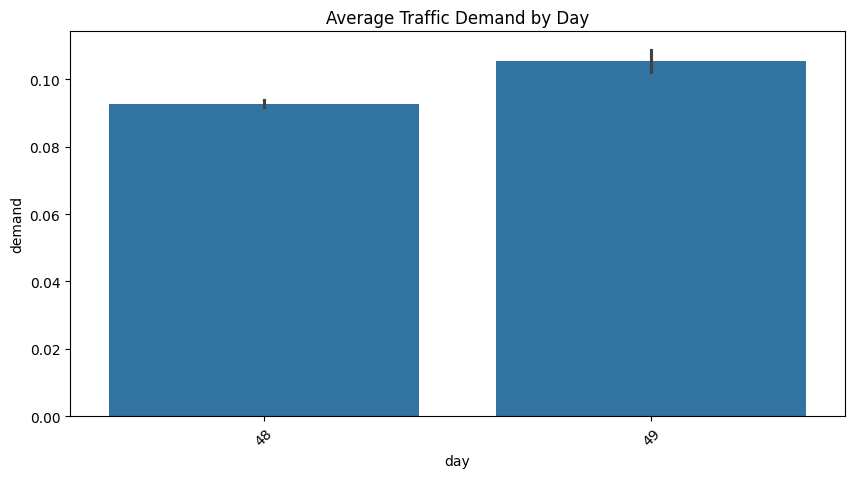

In [23]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='day',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Average Traffic Demand by Day')
plt.xticks(rotation=45)

plt.show()

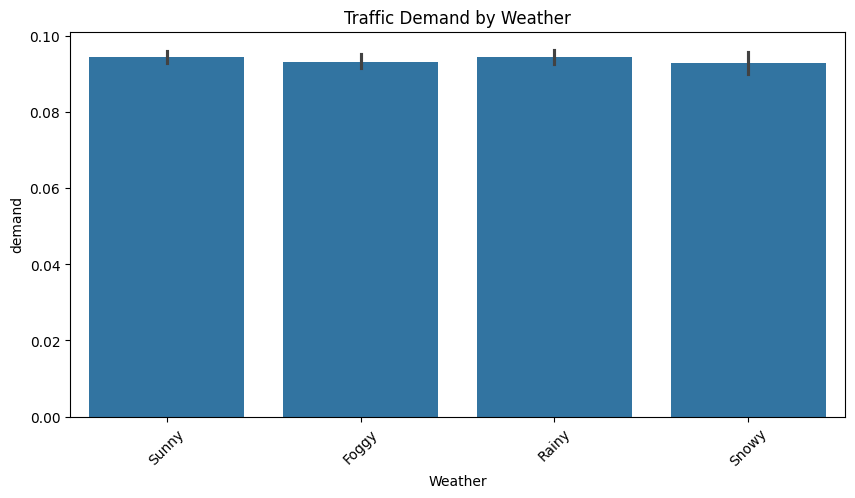

In [24]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Weather',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Traffic Demand by Weather')
plt.xticks(rotation=45)

plt.show()

In [25]:
df['Temperature'].min(), df['Temperature'].max()

(np.float64(-21.314644566266928), np.float64(48.2514326535093))

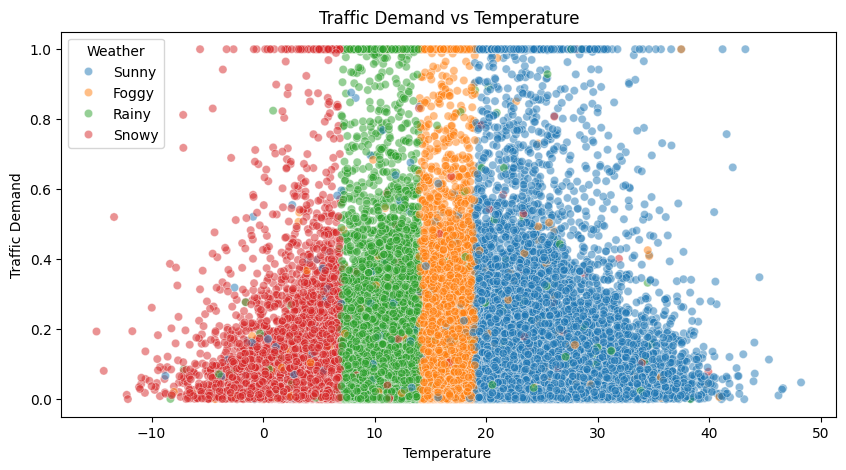

In [26]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Temperature',
    y='demand',
    hue='Weather',
    data=df,
    alpha=0.5
)
plt.title('Traffic Demand vs Temperature')


plt.xlabel('Temperature ')
plt.ylabel('Traffic Demand')
plt.show()

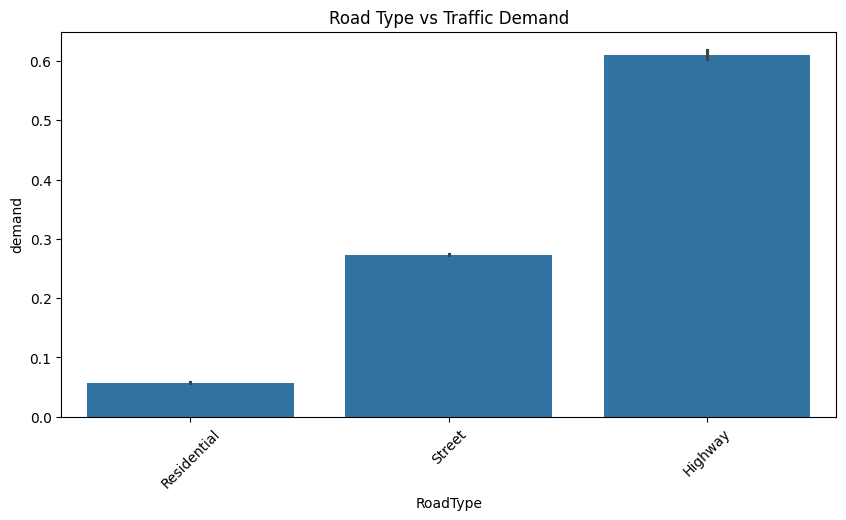

In [27]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='RoadType',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Road Type vs Traffic Demand')

plt.xticks(rotation=45)

plt.show()

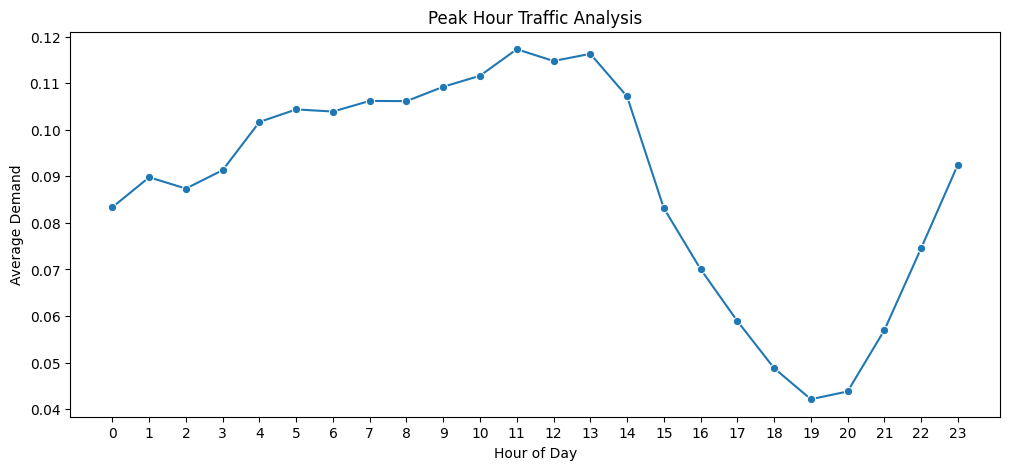

In [28]:
hourly_demand = df.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12,5))

sns.lineplot(
    x='hour',
    y='demand',
    data=hourly_demand,
    marker='o'
)

plt.title('Peak Hour Traffic Analysis')

plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')

plt.xticks(range(0,24))

plt.show()

In [29]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,test_file_id,hour,original_order_id,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,NaN,10,36776,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,NaN,10,37683,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,NaN,1,2911,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,NaN,2,8010,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,NaN,2,8905,qp02,45,165,0.659346,0.751840


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   119077 non-null  int64  
 1   geohash                 119077 non-null  str    
 2   day                     119077 non-null  int64  
 3   timestamp               119077 non-null  str    
 4   demand                  77299 non-null   float64
 5   RoadType                119077 non-null  str    
 6   NumberofLanes           119077 non-null  int64  
 7   LargeVehicles           119077 non-null  str    
 8   Landmarks               119077 non-null  str    
 9   Temperature             119077 non-null  float64
 10  Weather                 119077 non-null  str    
 11  is_train                119077 non-null  int64  
 12  test_file_id            41778 non-null   float64
 13  hour                    119077 non-null  int32  
 14  original_order_id       119077 

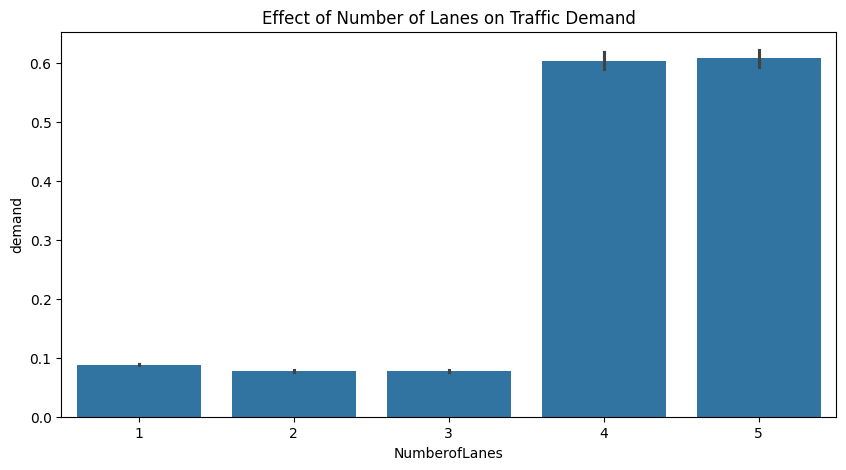

In [31]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='NumberofLanes',
    y='demand',
    data=df,
    estimator='mean'
)

plt.title('Effect of Number of Lanes on Traffic Demand')

plt.show()

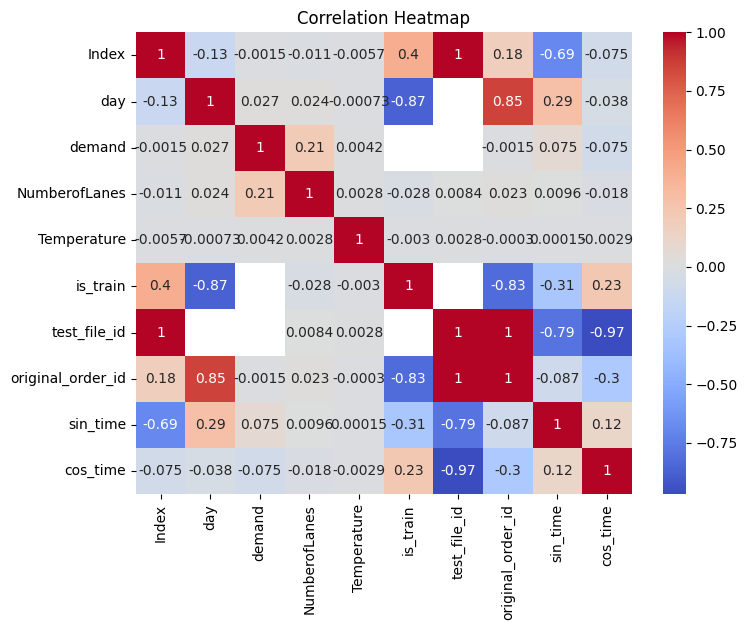

In [32]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

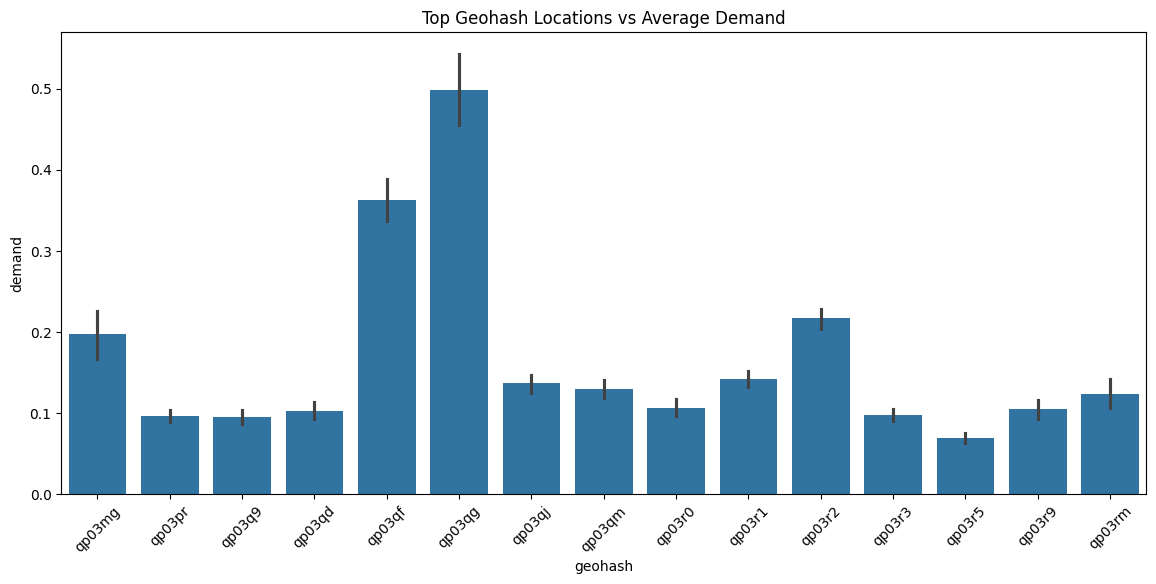

In [33]:
top_geohash = df['geohash'].value_counts().head(15).index

filtered_df = df[df['geohash'].isin(top_geohash)]

plt.figure(figsize=(14,6))

sns.barplot(
    x='geohash',
    y='demand',
    data=filtered_df,
    estimator='mean'
)

plt.title('Top Geohash Locations vs Average Demand')

plt.xticks(rotation=45)

plt.show()

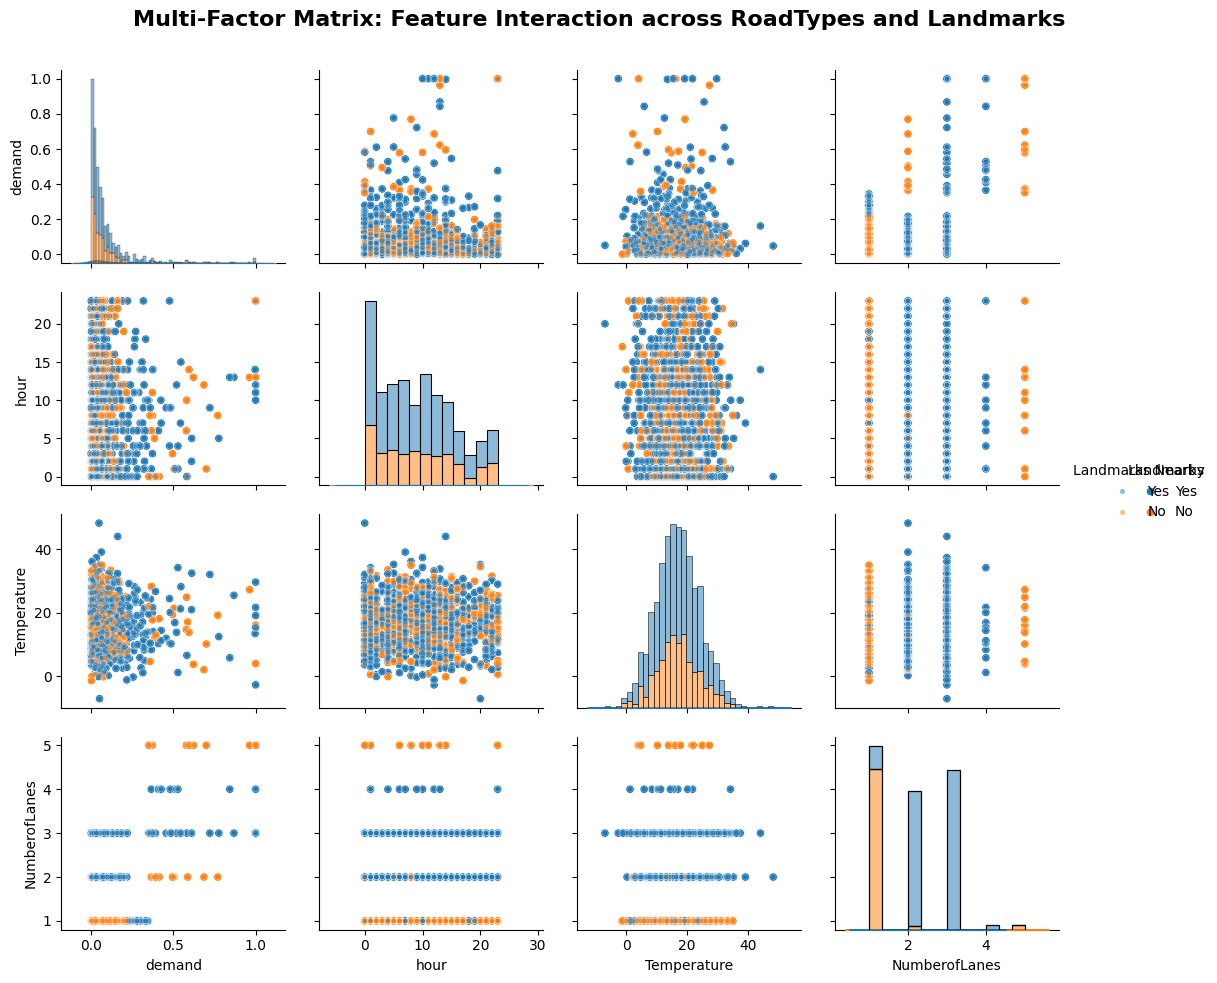

In [34]:
train_data = df[df['is_train'] == 1].copy()

# 2. Downsample randomly so the grid renders quickly without lagging your notebook
# (Processing a multi-categorical matrix on 77k+ rows takes a lot of memory)
train_sample = train_data.sample(n=1200, random_state=42)

# 3. Choose the numerical features you want to look at on the axes
numerical_vars = ['demand', 'hour', 'Temperature', 'NumberofLanes']

# 4. Initialize the custom PairGrid 
# col='RoadType' splits the plots side-by-side for each road layout
# hue='Landmarks' applies separate colors for landmark status
# ensure the sampled frame has an 'hour' (pairplot needs it)
train_sample = train_sample.copy()
if 'hour' not in train_sample.columns:
    temp = pd.to_datetime(train_sample['timestamp'], format='%H:%M', errors='coerce')
    if temp.isna().any():
        # fallback for non-zero-padded times like "1:0"
        temp = pd.to_datetime(train_sample['timestamp'], errors='coerce')
    train_sample['hour'] = temp.dt.hour
    train_sample['minute'] = temp.dt.minute
    train_sample['minutes_since_midnight'] = train_sample['hour'] * 60 + train_sample['minute']

# initialize a PairGrid faceted by RoadType, colored by Landmarks
g = sns.pairplot(
    train_sample,
    vars=numerical_vars,
    hue='Landmarks',
    
)

# 5. Map scatter plots to the off-diagonal intersection squares
g.map_offdiag(sns.scatterplot, alpha=0.5, s=15)

# 6. Map histograms to the diagonal squares to show separate feature distributions
g.map_diag(sns.histplot, multiple="stack", alpha=0.5)

# 7. Add a clean layout adjustments and a unified legend
g.add_legend(title="Landmarks Nearby", adjust_subtitles=True)
g.fig.subplots_adjust(top=0.92, wspace=0.15, hspace=0.15)
g.fig.suptitle('Multi-Factor Matrix: Feature Interaction across RoadTypes and Landmarks', fontsize=16, weight='bold')

# 8. Render the final plot matrix
plt.show()

In [35]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,is_train,test_file_id,hour,original_order_id,broad_region,minute,minutes_since_midnight,sin_time,cos_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,Sunny,1,NaN,10,36776,qp02,30,630,0.382683,-0.923880
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,Foggy,1,NaN,10,37683,qp02,45,645,0.321439,-0.946930
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,Rainy,1,NaN,1,2911,qp02,0,60,0.258819,0.965926
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,Sunny,1,NaN,2,8010,qp02,30,150,0.608761,0.793353
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,Foggy,1,NaN,2,8905,qp02,45,165,0.659346,0.751840


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119077 entries, 0 to 119076
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Index                   119077 non-null  int64  
 1   geohash                 119077 non-null  str    
 2   day                     119077 non-null  int64  
 3   timestamp               119077 non-null  str    
 4   demand                  77299 non-null   float64
 5   RoadType                119077 non-null  str    
 6   NumberofLanes           119077 non-null  int64  
 7   LargeVehicles           119077 non-null  str    
 8   Landmarks               119077 non-null  str    
 9   Temperature             119077 non-null  float64
 10  Weather                 119077 non-null  str    
 11  is_train                119077 non-null  int64  
 12  test_file_id            41778 non-null   float64
 13  hour                    119077 non-null  int32  
 14  original_order_id       119077 

In [37]:
import geohash2

# Extract latitude and longitude from geohash
df['latitude'] = df['geohash'].apply(lambda x: geohash2.decode(x)[0])
df['longitude'] = df['geohash'].apply(lambda x: geohash2.decode(x)[1])

# Display the results
df[['geohash', 'latitude', 'longitude']].head()

,geohash,latitude,longitude
0,qp02yc,-5.48,90.7
1,qp02yc,-5.48,90.7
2,qp02yc,-5.48,90.7
3,qp02yc,-5.48,90.7
4,qp02yc,-5.48,90.7


In [38]:
import lightgbm as lgb
import pygeohash as pgh
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
df['geohash_time_slot'] = df['geohash'].astype(str) + "_" + df['minutes_since_midnight'].astype(str)

df['te_geohash_time'] = np.nan
df['te_geohash_time'] = df['te_geohash_time'].astype('float64')

train_indices = df[df['is_train'] == 1].index
test_indices = df[df['is_train'] == 0].index

global_mean = float(df.loc[train_indices, 'demand'].mean())


kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in kf.split(train_indices):
    actual_train_idx = train_indices[train_idx]
    actual_val_idx = train_indices[val_idx]
    
    fold_train_stats = df.loc[actual_train_idx].groupby('geohash_time_slot')['demand'].mean()
    
    df.loc[actual_val_idx, 'te_geohash_time'] = df.loc[actual_val_idx, 'geohash_time_slot'].map(fold_train_stats).astype('float64')

df.loc[train_indices, 'te_geohash_time'] = df.loc[train_indices, 'te_geohash_time'].fillna(global_mean)


full_training_stats = df.loc[train_indices].groupby('geohash_time_slot')['demand'].mean()
df.loc[test_indices, 'te_geohash_time'] = df.loc[test_indices, 'geohash_time_slot'].map(full_training_stats).astype('float64')

df.loc[test_indices, 'te_geohash_time'] = df.loc[test_indices, 'te_geohash_time'].fillna(global_mean)

# 5. Drop the temporary cross-product string column
df.drop(columns=['geohash_time_slot'], inplace=True)

In [40]:
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,...,hour,original_order_id,broad_region,minute,minutes_since_midnight,sin_time,cos_time,latitude,longitude,te_geohash_time
0,36776,qp02yc,48,10:30,0.046790,Residential,1,Not Allowed,No,22.809028,...,10,36776,qp02,30,630,0.382683,-0.923880,-5.48,90.7,0.093942
1,37683,qp02yc,48,10:45,0.021158,Residential,1,Not Allowed,No,16.543659,...,10,37683,qp02,45,645,0.321439,-0.946930,-5.48,90.7,0.093942
2,2911,qp02yc,48,1:0,0.005397,Residential,3,Allowed,Yes,11.299877,...,1,2911,qp02,0,60,0.258819,0.965926,-5.48,90.7,0.093942
3,8010,qp02yc,48,2:30,0.012944,Residential,2,Not Allowed,Yes,32.142120,...,2,8010,qp02,30,150,0.608761,0.793353,-5.48,90.7,0.093942
4,8905,qp02yc,48,2:45,0.025961,Residential,1,Not Allowed,No,15.811063,...,2,8905,qp02,45,165,0.659346,0.751840,-5.48,90.7,0.093942


In [41]:
df.columns

Index(['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType',
       'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather',
       'is_train', 'test_file_id', 'hour', 'original_order_id', 'broad_region',
       'minute', 'minutes_since_midnight', 'sin_time', 'cos_time', 'latitude',
       'longitude', 'te_geohash_time'],
      dtype='str')

In [42]:
df = df.sort_values(by='original_order_id').reset_index(drop=True)
df['is_train'].head(100000)

0        1
1        1
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: is_train, Length: 100000, dtype: int64

In [43]:
# Test rows for day 49
df[df["day"] == 49]['is_train'].value_counts()

is_train
0    41778
1     7872
Name: count, dtype: int64

In [44]:
print("Aligning Day-48 Lookup ONLY for Day 49 Test Rows (is_train == 0)...")

# 1. Isolate ONLY the clean, verified training rows from Day 48
day48_clean_source = df[(df['day'] == 48) & (df['is_train'] == 1)][['geohash', 'minutes_since_midnight', 'demand']].copy()
day48_clean_source.rename(columns={'demand': 'extracted_d48_value'}, inplace=True)

# 2. Initialize the final column with NaN across the entire dataframe
df['demand_d48'] = np.nan

# 3. Create a mask specifically identifying Day 49 Test rows
test_rows_mask = (df['day'] == 49) & (df['is_train'] == 0)

# 4. Isolate just these test rows and merge yesterday's values onto them
day49_test_only = df[test_rows_mask].copy()
day49_test_only = pd.merge(day49_test_only, day48_clean_source, on=['geohash', 'minutes_since_midnight'], how='left')

# 5. Map the merged values back into the main dataframe using matched index alignment
df.loc[test_rows_mask, 'demand_d48'] = day49_test_only['extracted_d48_value'].values

# 6. Apply your safety target-encoding fallback ONLY to the test rows where Day 48 data was missing
# (Leaves Day 48 and Day 49 Train rows as completely clean NaNs)
df.loc[test_rows_mask, 'demand_d48'] = df.loc[test_rows_mask, 'demand_d48'].fillna(df['te_geohash_time'])

print("🎉 Golden feature 'demand_d48' populated strictly for Day 49 Test data!")

Aligning Day-48 Lookup ONLY for Day 49 Test Rows (is_train == 0)...
🎉 Golden feature 'demand_d48' populated strictly for Day 49 Test data!


In [45]:
print("Building continuous short-term lags for both Day 48 and Day 49...")

# 1. Create a continuous rolling timeline base for both days
# Day 48 rows keep their real actual demand history.
# Day 49 rows seamlessly transition to using the Day 48 mirror values.
df['short_term_proxy_base'] = np.where(
    df['day'] == 49,
    df['demand_d48'],   # For Day 49, use the Day 48 mirror sequence
    df['demand']        # For Day 48, use its own true live targets
)

# 2. Sort chronologically by location and time so sliding windows flow properly
df = df.sort_values(by=['geohash', 'day', 'minutes_since_midnight']).reset_index(drop=True)

# 3. Calculate your 15-minute and 30-minute lags across the entire dataset
# On Day 48, this pulls from Day 48's earlier morning slots.
# On Day 49, this pulls from the Day 48 proxy morning slots.
df['demand_lag_15m'] = df.groupby(['geohash'])['short_term_proxy_base'].shift(1)
df['demand_lag_30m'] = df.groupby(['geohash'])['short_term_proxy_base'].shift(2)

# 4. Calculate the 45-minute rolling average across the entire timeline
df['demand_rolling_mean_45m'] = df.groupby(['geohash'])['short_term_proxy_base'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# 5. Handle early morning boundaries (e.g., 12:15 AM rows) using target encoding safety nets
df['demand_lag_15m'] = df['demand_lag_15m'].fillna(df['te_geohash_time'])
df['demand_lag_30m'] = df['demand_lag_30m'].fillna(df['te_geohash_time'])
df['demand_rolling_mean_45m'] = df['demand_rolling_mean_45m'].fillna(df['te_geohash_time'])

# 6. Drop the temporary base helper column
df.drop(columns=['short_term_proxy_base'], inplace=True)

# 7. Snap everything back to your original submission file index order
df = df.sort_values(by='original_order_id').reset_index(drop=True)

print("🎉 Complete! Short-term features are fully active on both Day 48 and Day 49.")

Building continuous short-term lags for both Day 48 and Day 49...
🎉 Complete! Short-term features are fully active on both Day 48 and Day 49.


In [46]:
print("Calculating environmental compounding features...")
# Higher index = worse external conditions = higher potential ride demand
df['weather_stress_index'] = df['Temperature'] * (df['Weather'].isin(['Snowy', 'Rainy', 'Stormy']).astype(int) + 1)

Calculating environmental compounding features...


In [47]:
print("Mapping neighboring parent block radar values...")
# Extract the macro parent zone string prefix
df['parent_geohash'] = df['geohash'].str[:-1]

# Calculate global training baseline for neighboring blocks
parent_stats = df[df['is_train'] == 1].groupby('parent_geohash')['demand'].mean()
df['neighbor_historical_demand'] = df['parent_geohash'].map(parent_stats).fillna(df['demand'].mean())

# Safely drop temporary parent column
df.drop(columns=['parent_geohash'], inplace=True)

Mapping neighboring parent block radar values...


In [48]:
df['is_rush_hour'] = df['hour'].isin([8,9,10,17,18,19]).astype(int)
df['temp_x_lanes'] = df['Temperature'] * df['NumberofLanes']

In [49]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['minute_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
df['minute_cos'] = np.cos(2 * np.pi * df['minute'] / 60)

In [50]:
print("Engineering high-impact Road Type interaction features...")

# 1. Temporal-Infrastructure Interaction
# This creates a combined string signature like "Highway_8" or "Residential_17"
# It allows CatBoost to instantly map unique demand patterns for highways at specific hours
df['road_hour_interaction'] = df['RoadType'].astype(str) + "_" + df['hour'].astype(str)

# 2. Peak-Hour Impact Factor
# An explicit numeric multiplication: Highlights highway severity specifically during gridlock windows
# If 'is_peak_hour' is 1 and it's a highway, this value scales heavily with your target encoding baseline
df['highway_peak_momentum'] = np.where(df['RoadType'] == 'Highway', 1, 0) * df['is_rush_hour'] * df['te_geohash_time']

print("🎉 Highway tracking features successfully optimized!")

Engineering high-impact Road Type interaction features...
🎉 Highway tracking features successfully optimized!


In [51]:
print("Engineering Advanced Spatial Spillover & Cyclic Anchor Features...")

# 1. Break Spatial Isolation: Create Parent Traffic Zones
# Geohashes are hierarchical. If your geohashes are strings (e.g., 'w3u1fx'), 
# the first 5 characters represent the broader immediate neighborhood cluster.
df['geohash_zone'] = df['geohash'].astype(str).str.slice(0, 5)

# 2. Neighborhood Demand Velocity (Spatial Spillover Proxy)
# Tracks the average lag demand of the surrounding zone to see if traffic is spilling into this area
zone_lag_mean = df.groupby(['geohash_zone', 'day', 'minutes_since_midnight'])['demand_lag_15m'].transform('mean')
df['neighborhood_spillover_momentum'] = zone_lag_mean - df['demand_lag_15m']

# 3. Macro Zone Hourly Demand Baseline
# Computes the historical baseline for the entire zone at this specific hour
zone_hourly_baseline = df[df['is_train'] == 1].groupby(['geohash_zone', 'hour'])['demand'].mean().reset_index()
zone_hourly_baseline.rename(columns={'demand': 'zone_historical_hourly_base'}, inplace=True)
df = pd.merge(df, zone_hourly_baseline, on=['geohash_zone', 'hour'], how='left')
df['zone_historical_hourly_base'] = df['zone_historical_hourly_base'].fillna(df['te_geohash_time'])

# 4. Eliminate Day-of-the-Week Volatility (Hourly Deviation Anchor)
# Instead of relying blindly on yesterday's raw numbers, track how much the current lag 
# deviates from the location's median performance at this specific hour.
df['geohash_hourly_median'] = df.groupby(['geohash', 'hour'])['demand_lag_15m'].transform('median')
df['demand_deviation_from_median'] = df['demand_lag_15m'] - df['geohash_hourly_median']

print("🎉 Spatial-Temporal shockwave features successfully injected!")

Engineering Advanced Spatial Spillover & Cyclic Anchor Features...
🎉 Spatial-Temporal shockwave features successfully injected!


In [52]:
from sklearn.decomposition import TruncatedSVD
print("Generating Scenario 3: Latent Geohash Behavioral Profiles via SVD...")

# 1. Create a historical baseline pivot table (Geohash x Hour) using only training rows
historical_profile = df[df['is_train'] == 1].pivot_table(
    index='geohash', 
    columns='hour', 
    values='demand', 
    aggfunc='mean'
).fillna(0)

# 2. Decompose the 24 hourly dimensions into 2 core behavioral latent vectors
svd = TruncatedSVD(n_components=2, random_state=42)
geohash_embeddings = svd.fit_transform(historical_profile)

# 3. Build a mapping dataframe
embedding_df = pd.DataFrame(
    geohash_embeddings, 
    index=historical_profile.index, 
    columns=['geo_profile_latent_1', 'geo_profile_latent_2']
).reset_index()

# 4. Merge these structural 'personality coordinates' back into the main master dataframe
df = pd.merge(df, embedding_df, on='geohash', how='left')

# Fill missing profiles (for any test-only geohashes) with global defaults
df['geo_profile_latent_1'] = df['geo_profile_latent_1'].fillna(df['geo_profile_latent_1'].mean())
df['geo_profile_latent_2'] = df['geo_profile_latent_2'].fillna(df['geo_profile_latent_2'].mean())

print("🎉 Geohash latent behavioral vectors successfully embedded!")

Generating Scenario 3: Latent Geohash Behavioral Profiles via SVD...
🎉 Geohash latent behavioral vectors successfully embedded!


In [53]:
print("Engineering Scenario 4: Cross-Sectional Contemporary City Aggregates...")

# Calculate the average demand across ALL geohashes for every single unique 15-minute time slice
# If it's a test row, it will use the baseline proxies or available surrounding values
time_slice_city_load = df.groupby(['day', 'minutes_since_midnight'])['demand_lag_15m'].transform('mean')
df['city_wide_congestion_proxy'] = time_slice_city_load

print("🎉 Contemporary cross-sectional load tracking active!")

Engineering Scenario 4: Cross-Sectional Contemporary City Aggregates...
🎉 Contemporary cross-sectional load tracking active!


In [54]:
print("Engineering Scenario 2: Relative Hourly Deviation Anchors...")

# Isolate historical median benchmarks per geohash per hour slot
geohash_hourly_medians = df[df['is_train'] == 1].groupby(['geohash', 'hour'])['demand'].median().reset_index()
geohash_hourly_medians.rename(columns={'demand': 'historical_hourly_median_anchor'}, inplace=True)

# Merge the anchor back
df = pd.merge(df, geohash_hourly_medians, on=['geohash', 'hour'], how='left')
df['historical_hourly_median_anchor'] = df['historical_hourly_median_anchor'].fillna(df['te_geohash_time'])

# Calculate the clean, day-agnostic variance feature
df['current_demand_vs_historical_anchor'] = df['demand_lag_15m'] - df['historical_hourly_median_anchor']

print("🎉 Chronological day-of-week distortion anchor correction applied!")

Engineering Scenario 2: Relative Hourly Deviation Anchors...
🎉 Chronological day-of-week distortion anchor correction applied!


In [55]:
output_path = "df_export.csv"
df.to_csv(output_path, index=False)